# Bible Corpus: Pairwise Domain Distance

Downloads selected language bibles from https://github.com/christos-c/bible-corpus and evaluates
pairwise domain-distance metrics from `corpus_helpers.metrics` against two external ground truths:
URIEL typological feature distances and a manually specified phylogenetic tree.

**Languages** — chosen to give clear within-family and cross-family signal:
- **West Germanic**: `en` English, `de` German, `nl` Dutch
- **North Germanic**: `da` Danish, `sv` Swedish
- **West Slavic** (Latin script): `cs` Czech, `sk` Slovak, `pl` Polish
- **South Slavic** (Latin script): `hr` Croatian

**Dependency**: `pip install lang2vec` for the URIEL evaluation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import urllib.request
import xml.etree.ElementTree as ET
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from functools import partial
from corpus_helpers.read import (
    lower, 
    split_line, 
    delete_newline, 
    split_word, 
    delete_blank, 
    as_bytes, 
    chain_preprocessors
)

from corpus_helpers.metrics import (
    ngram_overlap,
    ngram_divergence,
    normalized_compression_distance,
    bpe_overlap, 
)

/Users/rastislavhronsky/Research/corpus-helpers/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download Bible XML files

In [2]:
LANGUAGES = {
    'en': 'English',
    'de': 'German',
    'nl': 'Dutch',
    'da': 'Danish',
    'sv': 'Swedish',
    'cs': 'Czech',
    'sk': 'Slovak',
    'pl': 'Polish',
    'hr': 'Croatian',
}
LANG_CODES = list(LANGUAGES.keys())
N = len(LANG_CODES)

RAW_BASE = 'https://raw.githubusercontent.com/christos-c/bible-corpus/master/bibles'
CACHE_DIR = Path('_bible_cache')
CACHE_DIR.mkdir(exist_ok=True)

def download(lang_code: str, lang_name: str) -> Path:
    dest = CACHE_DIR / f'{lang_code}.xml'
    if not dest.exists():
        url = f'{RAW_BASE}/{lang_name}.xml'
        print(f'Downloading {lang_name}...', end=' ', flush=True)
        urllib.request.urlretrieve(url, dest)
        print('done')
    else:
        print(f'{lang_name}: cached')
    return dest

paths = {code: download(code, name) for code, name in LANGUAGES.items()}

English: cached
German: cached
Dutch: cached
Danish: cached
Swedish: cached
Czech: cached
Slovak: cached
Polish: cached
Croatian: cached


## 2. Parse XML → list of verse bytes

In [3]:

PRETOKEN_PIPELINE = [lower, split_line, delete_newline, split_word, delete_blank, as_bytes]

def parse_bible(path: Path) -> list[bytes]:
    tree = ET.parse(path)
        # (seg.text or '').strip().encode('utf-8')
    segments = [(seg.text or '').strip() for seg in tree.iter('seg')
                if seg.text and seg.text.strip()]
    return chain_preprocessors(segments, PRETOKEN_PIPELINE)

paths = {code: download(code, name) for code, name in LANGUAGES.items()}
corpora: dict[str, list[bytes]] = {}
for code, path in paths.items():
    corpora[code] = parse_bible(path)
    print(f'{code}: {len(corpora[code]):,} verses')

English: cached
German: cached
Dutch: cached
Danish: cached
Swedish: cached
Czech: cached
Slovak: cached
Polish: cached
Croatian: cached
en: 918,445 verses
de: 820,005 verses
nl: 839,790 verses
da: 786,197 verses
sv: 860,278 verses
cs: 731,091 verses
sk: 746,897 verses
pl: 741,355 verses
hr: 697,515 verses


## 3. Compute pairwise distance matrices

In [6]:
import bz2, lzma, gzip
METRICS = [
    dict(label='ncd_bz2', fn=partial(normalized_compression_distance, compressor=bz2.compress, symmetric=True)),
    dict(label='ncd_lzma', fn=partial(normalized_compression_distance, compressor=lzma.compress, symmetric=True)),
    dict(label='ncd_gzip', fn=partial(normalized_compression_distance, compressor=gzip.compress, symmetric=True)),
    dict(label='jsd_word_n=1', fn=partial(ngram_divergence, method='jsd', n=1, unit='word')),
    dict(label='jsd_word_n=2', fn=partial(ngram_divergence, method='jsd', n=1, unit='word')),
    dict(label='jsd_char_n=3', fn=partial(ngram_divergence, method='jsd', n=3, unit='char')),
    dict(label='jsd_char_n=5', fn=partial(ngram_divergence, method='jsd', n=5, unit='char')),
    dict(label='jacc_word', fn=partial(ngram_overlap, n=1, unit='word')),
    dict(label='bpe_overlap', fn=partial(bpe_overlap, min_freq_fract=1e-6, show_progress=False)),
]

LANG_CODES = list(LANGUAGES.keys())
N = len(LANG_CODES)

METRIC_MATS = {m['label']: np.zeros((N, N)) for m in METRICS}
pairs = list(combinations(range(N), 2))
print(f'Computing {len(pairs)} pairs × {len(METRICS)} metrics...')

Computing 36 pairs × 9 metrics...


In [ ]:
for i, j in pairs:
    ca, cb = corpora[LANG_CODES[i]], corpora[LANG_CODES[j]]
    print(f"  {LANG_CODES[i]}-{LANG_CODES[j]}", end='  ', flush=True)
    for m in METRICS:
        val = m['fn'](ca, cb)
        METRIC_MATS[m['label']][i, j] = val
        METRIC_MATS[m['label']][j, i] = val
        print(f"{m['label']}={val:.4f}", end='  ', flush=True)
    print()

print('Done.')

Computing 36 pairs × 9 metrics...
  en-de  ncd_bz2=1.0197  ncd_lzma=0.9986  ncd_gzip=0.9999  jsd_word_n=1=0.5094  jsd_word_n=2=0.5094  jsd_char_n=3=0.1656  jsd_char_n=5=0.2346  jacc_word=0.0453  bpe_overlap=0.2960  
  en-nl  ncd_bz2=1.0188  ncd_lzma=0.9988  ncd_gzip=0.9999  jsd_word_n=1=0.5179  jsd_word_n=2=0.5179  jsd_char_n=3=0.1602  jsd_char_n=5=0.2304  jacc_word=0.0466  bpe_overlap=0.3251  
  en-da  ncd_bz2=1.0143  ncd_lzma=0.9991  ncd_gzip=0.9999  jsd_word_n=1=0.4975  jsd_word_n=2=0.4975  jsd_char_n=3=0.1752  jsd_char_n=5=0.2382  jacc_word=0.0337  bpe_overlap=0.2908  
  en-sv  ncd_bz2=1.0188  ncd_lzma=0.9992  ncd_gzip=0.9999  jsd_word_n=1=0.5162  jsd_word_n=2=0.5162  jsd_char_n=3=0.1824  jsd_char_n=5=0.2487  jacc_word=0.0306  bpe_overlap=0.2263  
  en-cs  ncd_bz2=1.0207  ncd_lzma=0.9995  ncd_gzip=1.0000  jsd_word_n=1=0.4781  jsd_word_n=2=0.4781  jsd_char_n=3=0.2706  jsd_char_n=5=0.3342  jacc_word=0.0142  bpe_overlap=0.1201  
  en-sk  ncd_bz2=1.0199  ncd_lzma=0.9996  ncd_gzip=0.999

In [9]:
import pickle
with open('_bible_cache/mats.pkl', 'wb') as f: 
    pickle.dump(METRIC_MATS, f)

## 4. URIEL evaluation

[URIEL](http://www.cs.cmu.edu/~dmortens/uriel.html) encodes typological properties of languages as feature vectors.
`lang2vec` provides convenient access. We fetch two feature sets and compute cosine distances:
- **`fam`** — one-hot language family membership (should closely match the gold tree)
- **`syntax_knn + phonology_knn + inventory_knn`** — typological features interpolated via k-NN

We then measure how well each corpus metric ranks pairs by Spearman ρ against the URIEL distances.

In [11]:
# setuptools ≥ 72 dropped pkg_resources; shim it before lang2vec imports it
import sys, types, importlib.util, os as _os
if 'pkg_resources' not in sys.modules:
    _pr = types.ModuleType('pkg_resources')
    def _resource_filename(pkg, path):
        spec = importlib.util.find_spec(pkg)
        return _os.path.join(_os.path.dirname(spec.origin), path)
    _pr.resource_filename = _resource_filename
    sys.modules['pkg_resources'] = _pr

import lang2vec.lang2vec as l2v
from sklearn.metrics.pairwise import cosine_distances

# ISO 639-3 codes expected by lang2vec
ISO3 = {
    'en': 'eng', 'de': 'deu', 'nl': 'nld', 'da': 'dan', 'sv': 'swe',
    'cs': 'ces', 'sk': 'slk', 'pl': 'pol', 'hr': 'hrv',
}
iso3_codes = [ISO3[c] for c in LANG_CODES]

URIEL_SETS = {
    'family (fam)':  'fam',                                    # one-hot language family membership
    'typological':   'syntax_knn+phonology_knn+inventory_knn', # interpolated typological features
}

uriel_mats: dict[str, np.ndarray] = {}
for name, fset in URIEL_SETS.items():
    feats = l2v.get_features(iso3_codes, fset)
    vecs = np.array([feats[c] for c in iso3_codes], dtype=float)
    # drop dimensions where any language has NaN
    valid = ~np.any(np.isnan(vecs), axis=0)
    vecs_clean = vecs[:, valid]
    print(f'{name}: {vecs.shape[1]} dims → {valid.sum()} after NaN filter')
    uriel_mats[name] = cosine_distances(vecs_clean)

# Quick sanity check: lowest family distances should be within-family
print()
print('Lowest family distances (should all be within-family):')
fam = uriel_mats['family (fam)']
idx = np.triu_indices(N, k=1)
order = np.argsort(fam[idx])
for rank, o in enumerate(order[:5]):
    i, j = idx[0][o], idx[1][o]
    print(f'  {rank+1}. {LANG_CODES[i]}-{LANG_CODES[j]}  d={fam[i,j]:.4f}')

family (fam): 3718 dims → 3718 after NaN filter
typological: 289 dims → 289 after NaN filter

Lowest family distances (should all be within-family):
  1. cs-sk  d=0.0871
  2. da-sv  d=0.1667
  3. sk-pl  d=0.2000
  4. cs-pl  d=0.2697
  5. de-nl  d=0.3196


In [12]:
!pip install jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]


In [13]:
def upper_tri(mat: np.ndarray) -> np.ndarray:
    i, j = np.triu_indices(len(mat), k=1)
    return mat[i, j]

# Spearman ρ between each corpus metric and each URIEL distance
rows = []
for metric_name, metric_mat in METRIC_MATS.items():
    for uriel_name, uriel_mat in uriel_mats.items():
        r, p = spearmanr(upper_tri(metric_mat), upper_tri(uriel_mat))
        rows.append({'metric': metric_name, 'URIEL': uriel_name, 'ρ': r, 'p': p})

df_corr = pd.DataFrame(rows).pivot(index='metric', columns='URIEL', values='ρ')
print('Spearman ρ (corpus metric vs URIEL distance):')
display(df_corr.style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.3f}'))

# p-values
df_p = pd.DataFrame(rows).pivot(index='metric', columns='URIEL', values='p')
print('\np-values:')
display(df_p.style.format('{:.4f}'))

Spearman ρ (corpus metric vs URIEL distance):


URIEL,family (fam),typological
metric,,
bpe_overlap,-0.619,-0.834
jacc_word,-0.670,-0.677
jsd_char_n=3,0.568,0.789
jsd_char_n=5,0.581,0.800
jsd_word_n=1,0.320,0.343
jsd_word_n=2,0.320,0.343
ncd_bz2,-0.173,0.140
ncd_gzip,0.479,0.409
ncd_lzma,0.725,0.818



p-values:


URIEL,family (fam),typological
metric,,
bpe_overlap,0.0001,0.0000
jacc_word,0.0000,0.0000
jsd_char_n=3,0.0003,0.0000
jsd_char_n=5,0.0002,0.0000
jsd_word_n=1,0.0567,0.0407
jsd_word_n=2,0.0567,0.0407
ncd_bz2,0.3120,0.4170
ncd_gzip,0.0031,0.0134
ncd_lzma,0.0000,0.0000


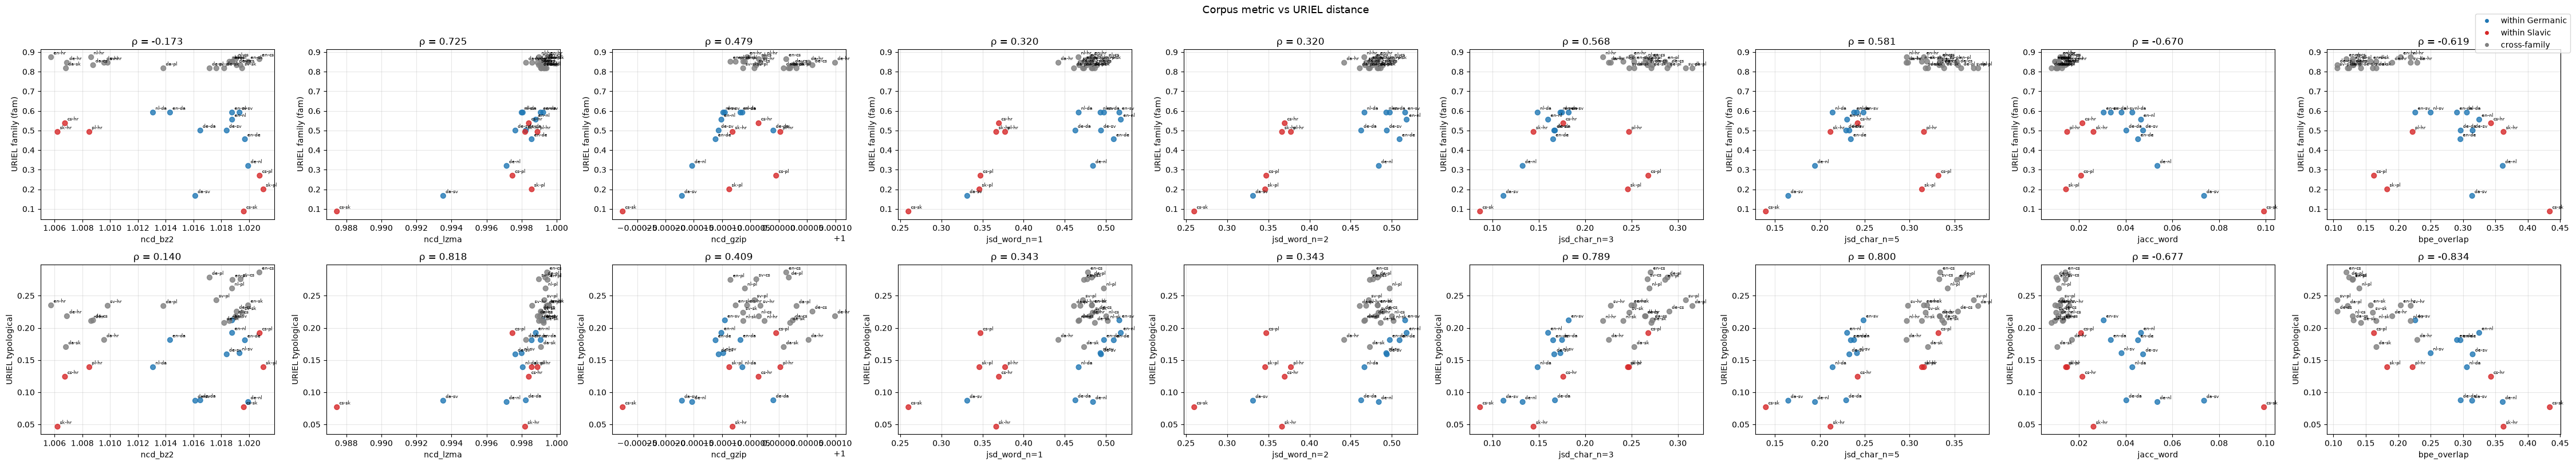

In [15]:
# Scatter: each metric vs each URIEL distance, one subplot per combination
fig, axes = plt.subplots(
    len(uriel_mats), len(METRIC_MATS),
    figsize=(5 * len(METRIC_MATS), 4 * len(uriel_mats)),
    squeeze=False,
)

pair_labels = [f'{LANG_CODES[i]}-{LANG_CODES[j]}'
               for i, j in zip(*np.triu_indices(N, k=1))]
family_colors = [
    'tab:blue' if LANG_CODES[i] in ('en','de','nl','da','sv')
               and LANG_CODES[j] in ('en','de','nl','da','sv')
    else 'tab:red' if LANG_CODES[i] in ('cs','sk','pl','hr')
                   and LANG_CODES[j] in ('cs','sk','pl','hr')
    else 'tab:grey'
    for i, j in zip(*np.triu_indices(N, k=1))
]

for row, (uriel_name, uriel_mat) in enumerate(uriel_mats.items()):
    u = upper_tri(uriel_mat)
    for col, (metric_name, metric_mat) in enumerate(METRIC_MATS.items()):
        ax = axes[row, col]
        m = upper_tri(metric_mat)
        r, _ = spearmanr(m, u)
        ax.scatter(m, u, c=family_colors, s=40, alpha=0.8, zorder=2)
        for lbl, mx, uy in zip(pair_labels, m, u):
            ax.annotate(lbl, (mx, uy), fontsize=6, ha='left', va='bottom',
                        xytext=(3, 2), textcoords='offset points')
        ax.set_xlabel(metric_name)
        ax.set_ylabel(f'URIEL {uriel_name}')
        ax.set_title(f'ρ = {r:.3f}')
        ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',  label='within Germanic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',   label='within Slavic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:grey',  label='cross-family'),
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.0))
fig.suptitle('Corpus metric vs URIEL distance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('bible_uriel_scatter.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

## 5. Asymmetric size experiment

Simulates a realistic setting where a large reference corpus is compared against
a much smaller target corpus. For each reference language, the target is **randomly
sampled to 1/10 of the reference byte size**.

The result is an **asymmetric N×N matrix**: `mat[ref, tgt]` is the distance from
the full reference corpus to the small target sample.

NCD metrics use `normalized_compression_distance_asymmetric` — `(C(ab) − C(a)) / C(b)` —
which is purpose-built for this regime. Other metrics use their standard implementations
applied to the sampled target; any asymmetry in the results comes purely from the size difference.


In [7]:
import random
from corpus_helpers.metrics import normalized_compression_distance_asymmetric

SIZE_RATIO = 10  # reference is this many times larger than target sample

ASYM_METRICS = [
    dict(label='ncd_bz2',  fn=partial(normalized_compression_distance_asymmetric, compressor=bz2.compress)),
    dict(label='ncd_lzma', fn=partial(normalized_compression_distance_asymmetric, compressor=lzma.compress)),
    dict(label='ncd_gzip', fn=partial(normalized_compression_distance_asymmetric, compressor=gzip.compress)),
    *[m for m in METRICS if not m['label'].startswith('ncd_')],
]

def sample_to_bytes(docs: list[bytes], target_bytes: int, seed: int = 42) -> list[bytes]:
    docs = list(docs)
    rng = random.Random(seed)
    order = list(range(len(docs)))
    rng.shuffle(order)
    sample, total = [], 0
    for i in order:
        sample.append(docs[i])
        total += len(docs[i])
        if total >= target_bytes:
            break
    return sample

ASYM_MATS = {m['label']: np.full((N, N), np.nan) for m in ASYM_METRICS}

for i, ref_code in enumerate(LANG_CODES):
    ref_corpus = corpora[ref_code]
    ref_bytes  = sum(len(d) for d in ref_corpus)
    target_bytes = ref_bytes // SIZE_RATIO
    print(f'ref={ref_code} ({ref_bytes/1e6:.1f}MB)  sample={target_bytes/1e3:.0f}KB', flush=True)
    for j, tgt_code in enumerate(LANG_CODES):
        if i == j:
            continue
        tgt_sample = sample_to_bytes(corpora[tgt_code], target_bytes)
        for m in ASYM_METRICS:
            ASYM_MATS[m['label']][i, j] = m['fn'](ref_corpus, tgt_sample)
    print('  done')

print('Done.')


ref=en (3.3MB)  sample=335KB
  done
ref=de (3.4MB)  sample=339KB
  done
ref=nl (3.3MB)  sample=334KB
  done
ref=da (3.0MB)  sample=299KB
  done
ref=sv (3.5MB)  sample=353KB
  done
ref=cs (3.3MB)  sample=329KB
  done
ref=sk (3.3MB)  sample=325KB
  done
ref=pl (3.4MB)  sample=343KB
  done
ref=hr (2.8MB)  sample=282KB
  done
Done.


In [8]:
import pickle
with open('_bible_cache/asym_mats.pkl', 'wb') as f: 
    pickle.dump(ASYM_MATS, f)

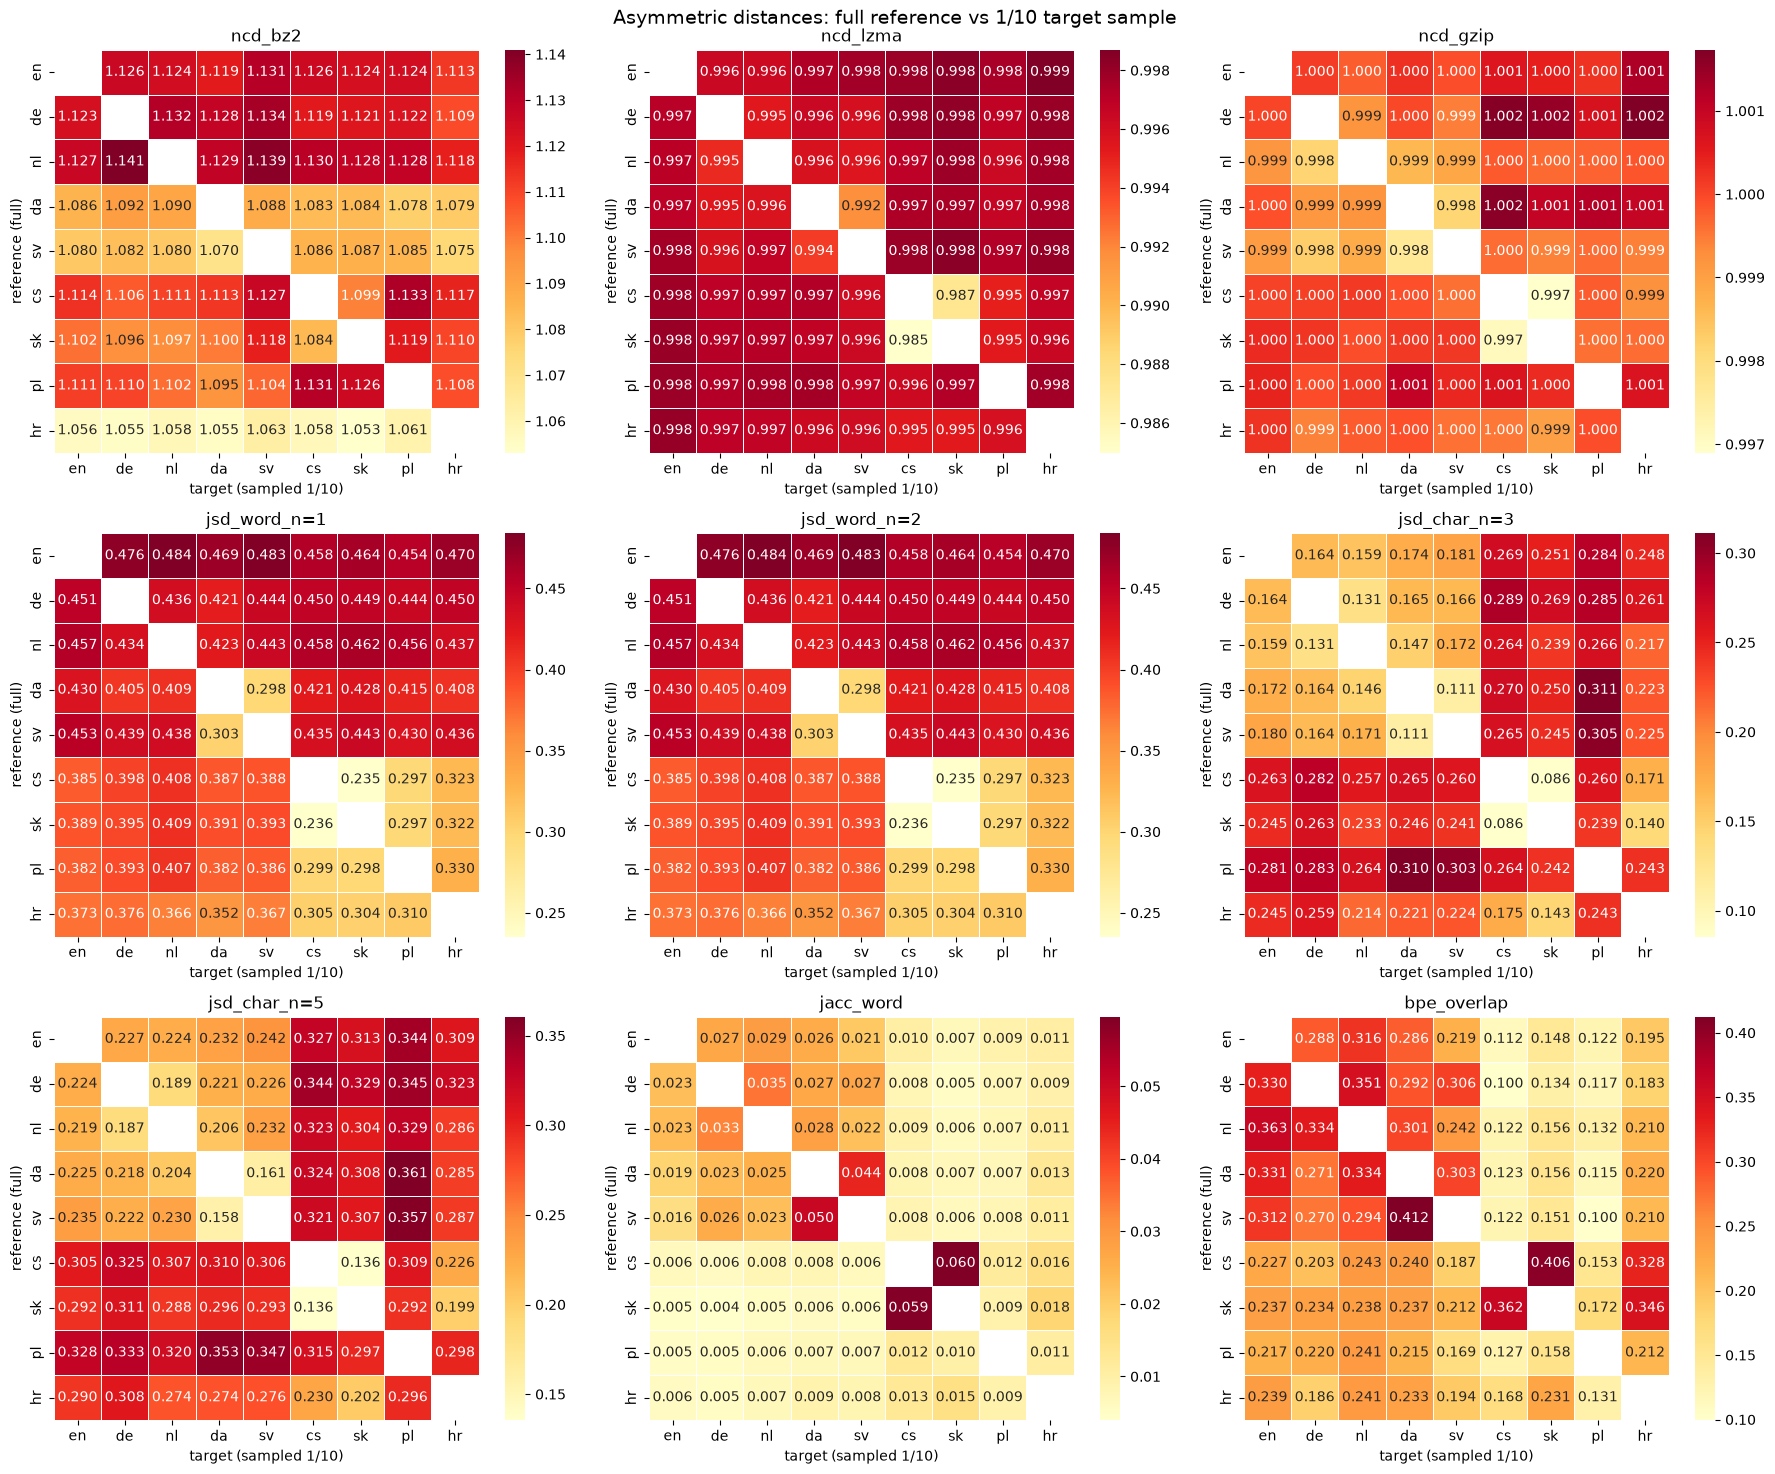

In [9]:
n_metrics = len(ASYM_METRICS)
ncols = 3
nrows = (n_metrics + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax, m in zip(axes, ASYM_METRICS):
    mat = ASYM_MATS[m['label']]
    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    sns.heatmap(
        mat,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        xticklabels=LANG_CODES,
        yticklabels=LANG_CODES,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.4,
        mask=np.eye(N, dtype=bool),
    )
    ax.set_title(m['label'])
    ax.set_xlabel('target (sampled 1/' + str(SIZE_RATIO) + ')')
    ax.set_ylabel('reference (full)')

for ax in axes[n_metrics:]:
    ax.set_visible(False)

fig.suptitle(
    f'Asymmetric distances: full reference vs 1/{SIZE_RATIO} target sample',
    fontsize=14,
)
plt.tight_layout()
plt.savefig('bible_asymmetric_size.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()


In [12]:
# All off-diagonal entries (both directions), since the matrix is asymmetric
off_diag = [(i, j) for i in range(N) for j in range(N) if i != j]

rows = []
for metric_name, metric_mat in ASYM_MATS.items():
    metric_vals = np.array([metric_mat[i, j] for i, j in off_diag])
    for uriel_name, uriel_mat in uriel_mats.items():
        uriel_vals = np.array([uriel_mat[i, j] for i, j in off_diag])
        r, p = spearmanr(metric_vals, uriel_vals)
        rows.append({'metric': metric_name, 'URIEL': uriel_name, 'rho': r, 'p': p})

df_asym_corr = pd.DataFrame(rows).pivot(index='metric', columns='URIEL', values='rho')
print('Spearman rho - asymmetric metrics vs URIEL (all off-diagonal pairs, both directions):')
display(df_asym_corr.style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.3f}'))

df_asym_p = pd.DataFrame(rows).pivot(index='metric', columns='URIEL', values='p')
print('\np-values:')
display(df_asym_p.style.format('{:.4f}'))


Spearman rho - asymmetric metrics vs URIEL (all off-diagonal pairs, both directions):


URIEL,family (fam),typological
metric,,
bpe_overlap,-0.431,-0.590
jacc_word,-0.676,-0.692
jsd_char_n=3,0.576,0.798
jsd_char_n=5,0.570,0.790
jsd_word_n=1,0.314,0.318
jsd_word_n=2,0.314,0.318
ncd_bz2,-0.114,0.031
ncd_gzip,0.443,0.506
ncd_lzma,0.670,0.648



p-values:


URIEL,family (fam),typological
metric,,
bpe_overlap,0.0002,0.0000
jacc_word,0.0000,0.0000
jsd_char_n=3,0.0000,0.0000
jsd_char_n=5,0.0000,0.0000
jsd_word_n=1,0.0072,0.0065
jsd_word_n=2,0.0072,0.0065
ncd_bz2,0.3410,0.7928
ncd_gzip,0.0001,0.0000
ncd_lzma,0.0000,0.0000


In [ ]:
dir_labels = [f'{LANG_CODES[i]}→{LANG_CODES[j]}' for i, j in off_diag]
dir_colors = [
    'tab:blue' if LANG_CODES[i] in ('en','de','nl','da','sv') and LANG_CODES[j] in ('en','de','nl','da','sv')
    else 'tab:red'  if LANG_CODES[i] in ('cs','sk','pl','hr')  and LANG_CODES[j] in ('cs','sk','pl','hr')
    else 'tab:grey'
    for i, j in off_diag
]

n_uriel   = len(uriel_mats)
n_metrics = len(ASYM_METRICS)
fig, axes = plt.subplots(
    n_uriel, n_metrics,
    figsize=(4 * n_metrics, 3.5 * n_uriel),
    squeeze=False,
)

for row, (uriel_name, uriel_mat) in enumerate(uriel_mats.items()):
    u = np.array([uriel_mat[i, j] for i, j in off_diag])
    for col, m in enumerate(ASYM_METRICS):
        ax = axes[row, col]
        mv = np.array([ASYM_MATS[m['label']][i, j] for i, j in off_diag])
        r, _ = spearmanr(mv, u)
        ax.scatter(mv, u, c=dir_colors, s=25, alpha=0.7, zorder=2)
        for lbl, x, y in zip(dir_labels, mv, u):
            ax.annotate(lbl, (x, y), fontsize=5, ha='left', va='bottom',
                        xytext=(2, 2), textcoords='offset points')
        ax.set_xlabel(m['label'], fontsize=8)
        ax.set_ylabel(f'URIEL {uriel_name}', fontsize=8)
        ax.set_title(f'ρ = {r:.3f}', fontsize=9)
        ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', label='within Germanic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',  label='within Slavic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:grey', label='cross-family'),
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=8)
fig.suptitle(
    f'Asymmetric metrics vs URIEL (full ref → 1/{SIZE_RATIO} target sample)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig('bible_asymmetric_uriel_scatter.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()
